<a href="https://colab.research.google.com/github/AfraazUlHaque/data-analytics/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andonians/random-linear-regression")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'random-linear-regression' dataset.
Path to dataset files: /kaggle/input/random-linear-regression


In [8]:
class lreg:
    def __init__(self):
        self.m=None
        self.b=None

    def fit(self,x,y):
        self.m=(np.mean(x*y)-np.mean(x)*np.mean(y))/(np.mean(x*x)-np.mean(x)*np.mean(x))
        self.b=np.mean(y)-self.m*np.mean(x)

    def predict(self,x):
        return self.m*x+self.b



In [66]:
df1=pd.read_csv(r"/kaggle/input/random-linear-regression/train.csv")

In [67]:
df1

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984
...,...,...
695,58.0,58.595006
696,93.0,94.625094
697,82.0,88.603770
698,66.0,63.648685


In [70]:
from sklearn.model_selection import train_test_split
x_train1,x_test1,y_train1,y_test1=train_test_split(df1.x,df1.y,test_size=0.2,random_state=2)

In [71]:
lr=lreg()

In [72]:
lr.fit(x_train1,y_train1)

In [77]:
y_pred1=lr.predict(x_test1)

In [78]:
from sklearn.metrics import r2_score,mean_squared_error
r2_score(y_test1,y_pred1)

0.9919683912145719

In [76]:
y_test1=y_test1.drop(213)
x_test1=x_test1.drop(213)

In [79]:
mean_squared_error(y_test1,y_pred1)

6.5508924793630285

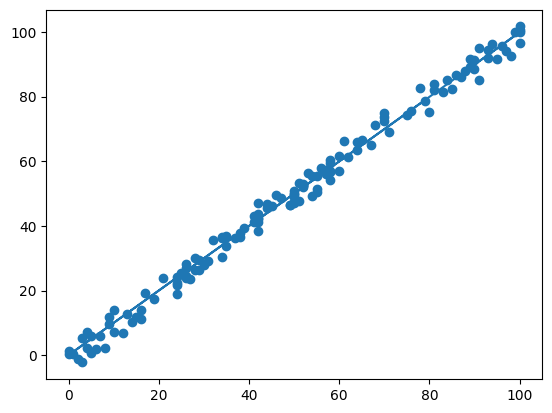

In [80]:
plt.plot(x_test1,y_pred1)
plt.scatter(x_test1,y_test1)
plt.show()

In [47]:
y_test=y_test.drop(213)

In [48]:
x_test=x_test.drop(213)

In [50]:
y_pred.shape

(140,)

In [148]:
class multiple_lreg:
    def __init__(self):
        self.b=None

    def fit(self,x,y):
        x=np.insert(x,0,1,axis=1)
        self.b=(np.linalg.inv(np.dot(x.T,x))).dot(x.T).dot(y)

    def predict(self,x):
        x=np.insert(x,0,1,axis=1)
        return np.dot(x,self.b)

In [137]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("volkanyalc/multi-linear-regression")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'multi-linear-regression' dataset.
Path to dataset files: /kaggle/input/multi-linear-regression


In [138]:
df=pd.read_csv(r"/root/.cache/kagglehub/datasets/volkanyalc/multi-linear-regression/versions/1/real_estate_price_size_year_view_multi.csv")

In [139]:
df.sample(5)

,price,size,year,view
83,282683.544,643.09,2018,Sea view
95,252460.400,549.80,2009,Sea view
27,406852.304,1334.10,2015,Sea view
7,175716.480,620.82,2006,No sea view
3,401255.608,1504.75,2015,No sea view


In [140]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop("price",axis=1),df.price,test_size=0.2,random_state=2)

In [141]:
scaler=StandardScaler()
scaler.fit(x_train['size'].values.reshape(-1,1))
x_train_trans=scaler.transform(x_train['size'].values.reshape(-1,1))
x_test_trans=scaler.transform(x_test['size'].values.reshape(-1,1))

In [142]:
ohe=OneHotEncoder()
ohe.fit(x_train[['year','view']])
x_train_trans1=ohe.transform(x_train[['year','view']])
x_test_trans1=ohe.transform(x_test[['year','view']])

In [143]:
x_train=np.hstack((x_train_trans,x_train_trans1.toarray()))
x_test=np.hstack((x_test_trans,x_test_trans1.toarray()))

In [149]:
mlr=multiple_lreg()
mlr.fit(x_train,y_train)

In [151]:
y_pred=mlr.predict(x_test)

In [152]:
r2_score=r2_score(y_test,y_pred)
r2_score

-2210.164352581082

In [153]:
y_pred

array([ 4410458.83243882, -6379301.63241646,  3609230.56348611,
       -3599390.0276159 ,  3106607.31412734,  1573203.51356559,
        4181164.20181661,  4147403.21104378,  3186323.15561874,
        3575660.53444572, -5454551.5512165 ,  3206117.84613137,
        5205734.43930226, -4577889.59599999,  1756742.23875748,
        1619283.19832029,  3024868.11437964,  3012520.34832752,
        1838290.47677273, -4743223.09281706])

numpy.ndarray